### Visualise a volume

In [1]:
# choose the coil setting
coil = 12 # or 32
# choose the idx of the volume you want to display idx \in {0, ..., 9}
idx_vol = 9 # The 9th 12-coil volume is the one named 'e14553s5_P44544.7.h5' in Test/12coil
# if coil==12:
#     psnrs_ncpdnet, psnrs_grappa, psnrs_wv, psnrs_tv, psnrs_wcrr, psnrs_drunet = psnrs_ncpdnet_12, psnrs_grappa_12, psnrs_wv_12, psnrs_tv_12, psnrs_wcrr_12, psnrs_drunet_12
#     ssims_ncpdnet, ssims_grappa, ssims_wv, ssims_tv, ssims_wcrr, ssims_drunet = ssims_ncpdnet_12, ssims_grappa_12, ssims_wv_12, ssims_tv_12, ssims_wcrr_12, ssims_drunet_12
# elif coil==32:
#     psnrs_ncpdnet, psnrs_grappa, psnrs_wv, psnrs_tv, psnrs_wcrr, psnrs_drunet = psnrs_ncpdnet_32, psnrs_grappa_32, psnrs_wv_32, psnrs_tv_32, psnrs_wcrr_32, psnrs_drunet_32
#     ssims_ncpdnet, ssims_grappa, ssims_wv, ssims_tv, ssims_wcrr, ssims_drunet = ssims_ncpdnet_32, ssims_grappa_32, ssims_wv_32, ssims_tv_32, ssims_wcrr_32, ssims_drunet_32

import torch
import matplotlib.pyplot as plt
from utils import psnr, ssim, nmse

traj_name = "gs.bin" # The name of the trajectory file used for reconstructions

# Load the reconstructions
x_gt = torch.load(f"savings_{coil}coil_{traj_name[:-4]}/volume_{idx_vol}_gt.pt", weights_only=True)
x_ncpdnet = torch.load(f"savings_{coil}coil_{traj_name[:-4]}/volume_{idx_vol}_ncpdnet.pt", weights_only=True)
x_grappa = torch.load(f"savings_{coil}coil_{traj_name[:-4]}/volume_{idx_vol}_grappa.pt", weights_only=True)
x_wv = torch.load(f"savings_{coil}coil_{traj_name[:-4]}/volume_{idx_vol}_wv.pt", weights_only=True)
x_tv = torch.load(f"savings_{coil}coil_{traj_name[:-4]}/volume_{idx_vol}_tv.pt", weights_only=True)
x_wcrr = torch.load(f"savings_{coil}coil_{traj_name[:-4]}/volume_{idx_vol}_wcrr.pt", weights_only=True)
x_dpir = torch.load(f"savings_{coil}coil_{traj_name[:-4]}/volume_{idx_vol}_drunet.pt", weights_only=True)
x_postp = torch.load(f"savings_{coil}coil_{traj_name[:-4]}/volume_{idx_vol}_postprocess.pt", weights_only=True)
x_diff = torch.load(f"savings_{coil}coil_{traj_name[:-4]}/volume_{idx_vol}_score-diff.pt", weights_only=True)

/LOCAL/wacg/conda/envs/metech1env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Function to plot an image with a zoomed-in inset
def plot_with_zoom(ax, img, title, psnr=float("inf"), ssim=1.0, nmse=1.0, display=False, title_display=False, arrow=False, start_arrow_coords=(0,0), end_arrow_coords=(0,0), color='gold'):
    if title_display:
        ax.set_title(title, fontsize=16, fontweight="bold")
    ax.imshow(img.detach().cpu().squeeze(), cmap="gray")
    ax.set_xticks([])
    ax.set_yticks([])
    if display:
        
        ax.text(
            0.02, 0.98, f"m-psnr: {psnr:.2f} db",
            color="white",
            fontsize=14,
            fontweight="bold",
            ha="left",
            va="top",
            transform=ax.transAxes
        )
        ax.text(
            0.02, 0.90, f"m-ssim: {ssim:.4f}",
            color="white",
            fontsize=14,
            fontweight="bold",
            ha="left",
            va="top",
            transform=ax.transAxes
        )
        ax.text(
            0.02, 0.82, f"m-nmse: {nmse:.4f}",
            color="white",
            fontsize=14,
            fontweight="bold",
            ha="left",
            va="top",
            transform=ax.transAxes
    )

    # Crop the region of interest
    cropped_img = img[crop_y:crop_y+crop_size, crop_x:crop_x+crop_size].detach().cpu().squeeze()

    # Add zoomed-in inset
    inset_ax = fig.add_axes([ax.get_position().x1 - 0.164, ax.get_position().y0 - 0.22, 0.30, 0.30])  # Adjust position
    inset_ax.imshow(cropped_img, cmap="gray")
    inset_ax.set_xticks([])
    inset_ax.set_yticks([])
    inset_ax.set_frame_on(True)
    inset_ax.spines['bottom'].set_color('green')
    inset_ax.spines['top'].set_color('green') 
    inset_ax.spines['right'].set_color('green')
    inset_ax.spines['left'].set_color('green')
    if arrow:
        # Arrow from point (x1, y1) to (x2, y2)
        inset_ax.annotate(
            '',                     # no text
            xy=end_arrow_coords,            # arrow tip
            xytext=start_arrow_coords,        # arrow start
            arrowprops=dict(
                arrowstyle='simple',
                color=color,        # arrow color
                ec='black',    # black contour
                lw=1.5,        # contour thickness
                mutation_scale=18   # controls arrow head size
            )
        )

    # Draw a green rectangle on the main image to indicate the zoomed-in region
    rect = plt.Rectangle((crop_x, crop_y), crop_size, crop_size, edgecolor='red', facecolor='none', linewidth=1)
    ax.add_patch(rect)
    
    return None

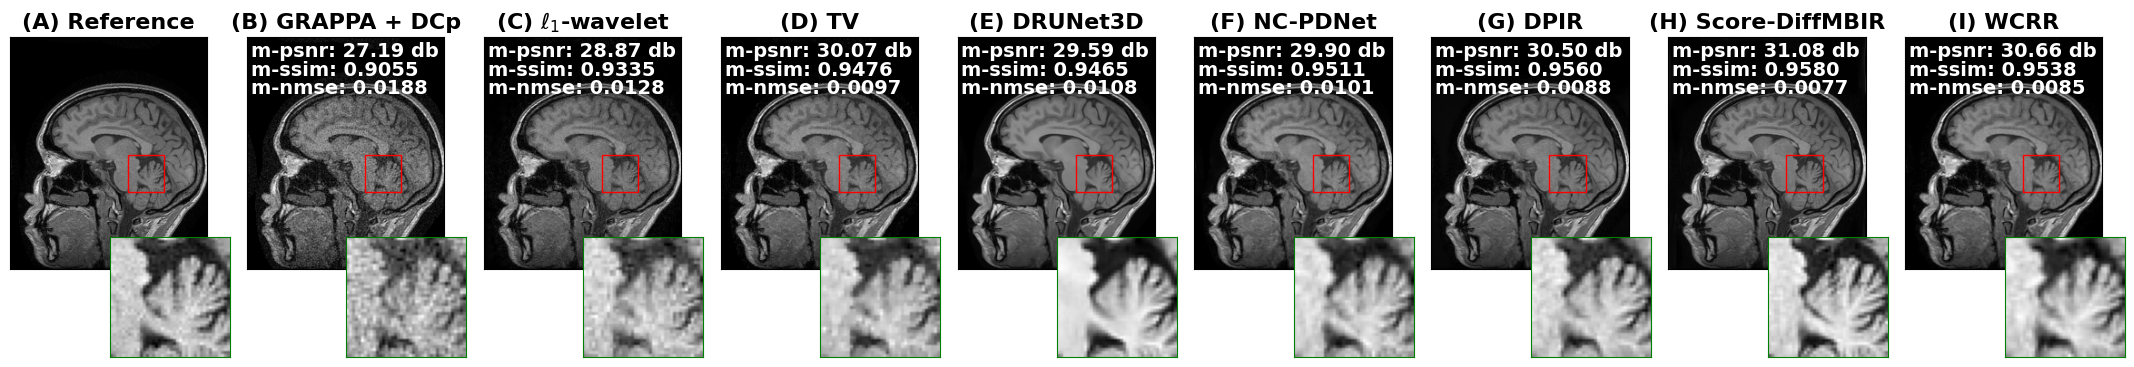

In [8]:
# Define the crop region (adjust these values as needed)
crop_x, crop_y = 130, 130  # Top-left corner of the cropped region
crop_size = 40  # Size of the cropped region

fig, ax = plt.subplots(1, 9, figsize=(3*9,4))

idx = [x_gt.shape[i] // 2 - 5 for i in range(-3,0)]
#idx[-1] -= 5
# Plot images with zoomed-in areas
plot_with_zoom(ax[0], x_gt[...,idx[-1]], f"(A) Reference", display=False, title_display=True)
plot_with_zoom(ax[1], x_grappa[...,idx[-1]], f"(B) GRAPPA + DCp", psnr(x_grappa, x_gt), ssim(x_grappa, x_gt), nmse(x_grappa, x_gt), display=True, title_display=True)
plot_with_zoom(ax[2], x_wv[...,idx[-1]], rf"(C) $\ell_1$-wavelet", psnr(x_wv, x_gt), ssim(x_wv, x_gt), nmse(x_wv, x_gt), display=True, title_display=True)
plot_with_zoom(ax[3], x_tv[...,idx[-1]], f"(D) TV", psnr(x_tv, x_gt), ssim(x_tv, x_gt), nmse(x_tv, x_gt), display=True, title_display=True)
plot_with_zoom(ax[4], x_postp[...,idx[-1]], f"(E) DRUNet3D", psnr(x_postp, x_gt), ssim(x_postp, x_gt), nmse(x_postp, x_gt), display=True, title_display=True)
plot_with_zoom(ax[5], x_ncpdnet[...,idx[-1]], f"(F) NC-PDNet", psnr(x_ncpdnet, x_gt), ssim(x_ncpdnet, x_gt), nmse(x_ncpdnet, x_gt), display=True, title_display=True)
plot_with_zoom(ax[6], x_dpir[...,idx[-1]], f"(G) DPIR", psnr(x_dpir, x_gt), ssim(x_dpir, x_gt), nmse(x_dpir, x_gt), display=True, title_display=True)
plot_with_zoom(ax[7], x_diff[...,idx[-1]], f"(H) Score-DiffMBIR", psnr(x_diff, x_gt), ssim(x_diff, x_gt), nmse(x_diff, x_gt), display=True, title_display=True)
plot_with_zoom(ax[8], x_wcrr[...,idx[-1]], f"(I) WCRR", psnr(x_wcrr, x_gt), ssim(x_wcrr, x_gt), nmse(x_wcrr, x_gt), display=True, title_display=True)
plt.savefig(f"savings_{coil}coil_gs/sagittal_{coil}coil_example.pdf", bbox_inches ='tight')
plt.show()

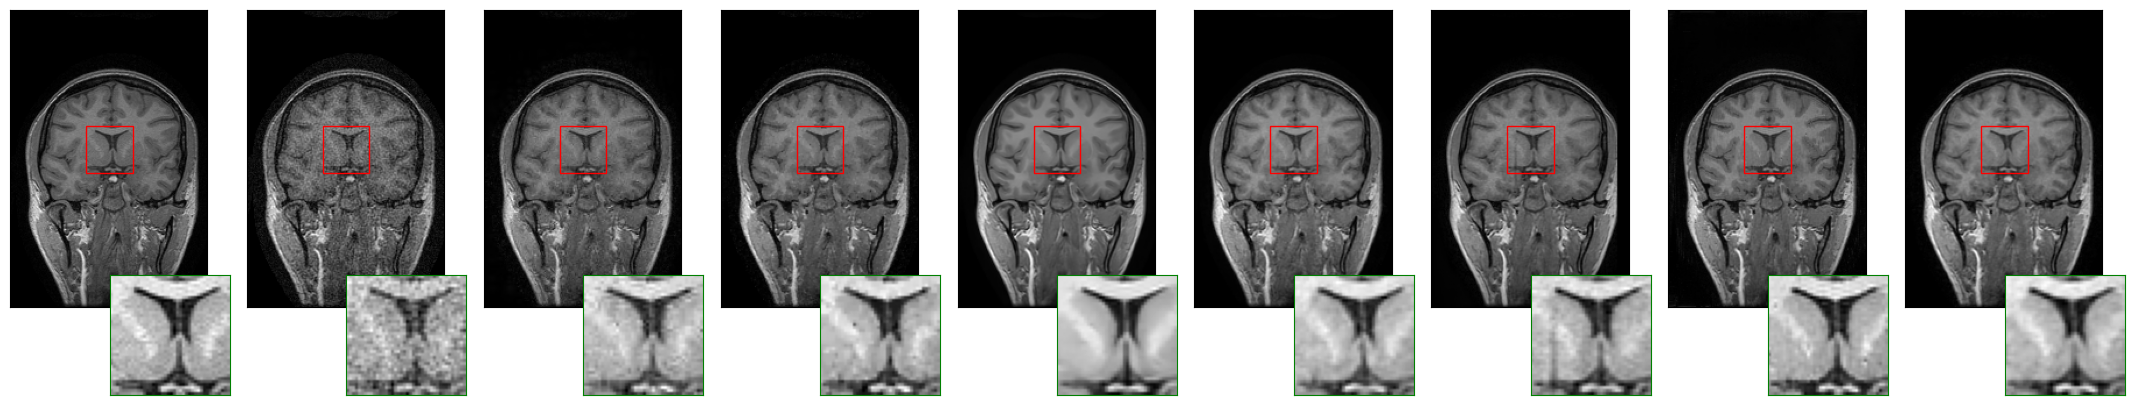

In [9]:
# Define the crop region (adjust these values as needed)
crop_x, crop_y = 65, 100  # Top-left corner of the cropped region
crop_size = 40  # Size of the cropped region

fig, ax = plt.subplots(1, 9, figsize=(3*9,4))

#idx = [x_gt.shape[i] // 2 for i in range(-3,0)]
# Plot images with zoomed-in areas
plot_with_zoom(ax[0], x_gt[:, idx[-2], :], f"Reference", title_display=False)
plot_with_zoom(ax[1], x_grappa[:, idx[-2], :], f"GRAPPA", arrow=False, start_arrow_coords=(24, 25), end_arrow_coords=(8, 20), color="#009E73")
plot_with_zoom(ax[2], x_wv[:, idx[-2], :], f"Wavelets", title_display=False)
plot_with_zoom(ax[3], x_tv[:, idx[-2], :], f"TV", title_display=False)
plot_with_zoom(ax[4], x_postp[:, idx[-2], :], f"DRUNet3D", title_display=False)
plot_with_zoom(ax[5], x_ncpdnet[:, idx[-2], :], f"NC-PDNet", arrow=False, start_arrow_coords=(24, 25), end_arrow_coords=(8, 20), color="#009E73")
plot_with_zoom(ax[6], x_dpir[:, idx[-2], :], f"DPIR", arrow=False, start_arrow_coords=(24, 25), end_arrow_coords=(8, 20), color="#D55E00")
plot_with_zoom(ax[7], x_diff[:, idx[-2], :], f"Score-DiffMBIR", arrow=False, start_arrow_coords=(24, 25), end_arrow_coords=(8, 20), color="#009E73")
plot_with_zoom(ax[8], x_wcrr[:, idx[-2], :], f"WCRR", arrow=False, start_arrow_coords=(24, 25), end_arrow_coords=(8, 20), color="#009E73")
plt.savefig(f"savings_{coil}coil_gs/coronal_{coil}coil_example.pdf", bbox_inches='tight')
plt.show()

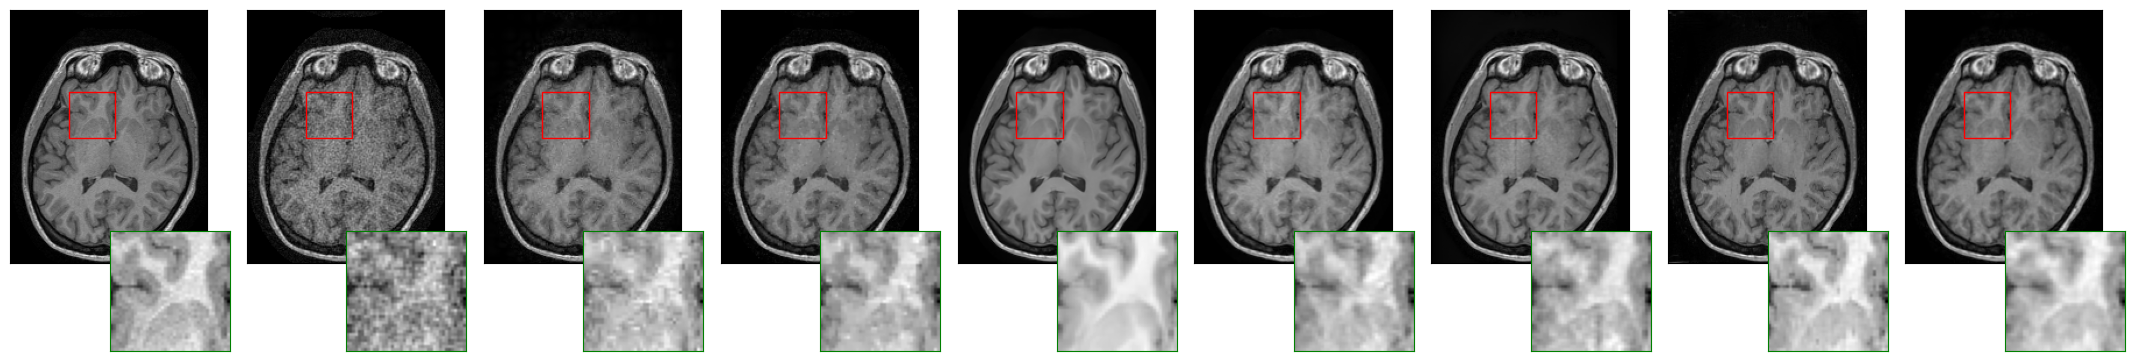

In [10]:
# Define the crop region (adjust these values as needed)
crop_x, crop_y = 50, 70  # Top-left corner of the cropped region
crop_size = 40  # Size of the cropped region

fig, ax = plt.subplots(1, 9, figsize=(3*9,4))

#idx = [x_gt.shape[i] // 2 for i in range(-3,0)]
# Plot images with zoomed-in areas
plot_with_zoom(ax[0], x_gt[idx[-3], :, :], f"Reference", title_display=False)
plot_with_zoom(ax[1], x_grappa[idx[-3], :, :], f"GRAPPA", arrow=False, start_arrow_coords=(24, 25), end_arrow_coords=(8, 20), color="#009E73")
plot_with_zoom(ax[2], x_wv[idx[-3], :, :], f"Wavelets", title_display=False)
plot_with_zoom(ax[3], x_tv[idx[-3], :, :], f"TV", title_display=False)
plot_with_zoom(ax[4], x_postp[idx[-3], :, :], f"DRUNet3D", title_display=False)
plot_with_zoom(ax[5], x_ncpdnet[idx[-3], :, :], f"NC-PDNet", arrow=False, start_arrow_coords=(24, 25), end_arrow_coords=(8, 20), color="#009E73")
plot_with_zoom(ax[6], x_dpir[idx[-3], :, :], f"DPIR", arrow=False, start_arrow_coords=(24, 25), end_arrow_coords=(8, 20), color="#D55E00")
plot_with_zoom(ax[7], x_diff[idx[-3], :, :], f"Score-DiffMBIR", arrow=False, start_arrow_coords=(24, 25), end_arrow_coords=(8, 20), color="#009E73")
plot_with_zoom(ax[8], x_wcrr[idx[-3], :, :], f"WCRR", arrow=False, start_arrow_coords=(24, 25), end_arrow_coords=(8, 20), color="#009E73")
plt.savefig(f"savings_{coil}coil_gs/transversal_{coil}coil_example.pdf", bbox_inches='tight')
plt.show()